# Notebook 1: Thermoelastic Stress Model for Seismic Velocity Changes

## Companion to: *Monitoring Velocity Change Over 20 Years at Parkfield* (Okubo et al., 2024)

This notebook develops the thermoelastic model linking surface temperature variations
to changes in seismic velocity ($dv/v$). We follow the framework of **Berger (1975)** as 
formulated by **Richter et al. (2014)** and applied in **Okubo et al. (2024)**, **Clements & Denolle (2023)**, 
and **Ermert et al. (2023)**.

### Physical Framework

Temperature fluctuations at Earth's surface diffuse downward, inducing thermoelastic
stresses that modify effective elastic moduli through nonlinear (third-order) elasticity.
The key chain is:

$$\Delta T_{\text{surface}} \xrightarrow{\text{diffusion}} T(z,t) \xrightarrow{\text{thermo-elastic}} \sigma(z,t) \xrightarrow{\text{nonlinear elast.}} \frac{dv}{v}(z,t)$$

### References
- Berger, J. (1975). *A note on thermoelastic strains and tilts.* JGR, 80, 274–277.
- Richter, T., et al. (2014). *Comprehensive observation and modeling of earthquake and temperature-related seismic velocity changes.* JGR Solid Earth, 119, 4747–4765.
- Okubo, K., Delbridge, B. G., & Denolle, M. A. (2024). *Monitoring velocity change over 20 years at Parkfield.* JGR Solid Earth, 129, e2023JB028084.
- Ermert, L. A., et al. (2023). *Probing environmental and tectonic changes underneath Mexico City with the urban seismic field.* Solid Earth, 14, 529–549.
- Clements, T. & Denolle, M. A. (2023). *The seismic signature of California's earthquakes, droughts, and floods.* JGR Solid Earth, 128, e2022JB025553.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.special import erfc
import matplotlib.gridspec as gridspec

# Publication-quality settings
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'serif', 'mathtext.fontset': 'cm',
    'axes.grid': True, 'grid.alpha': 0.3
})
print("Environment ready.")


Environment ready.


## 1. Temperature Diffusion into the Subsurface

The temperature at depth $z$ and time $t$ due to a periodic surface temperature
$T_0 \cos(\omega t)$ is governed by the heat equation:

$$\frac{\partial T}{\partial t} = \kappa_T \frac{\partial^2 T}{\partial z^2}$$

The solution is:

$$T(z,t) = T_0 \, e^{-\gamma z} \cos(\omega t - \gamma z)$$

where $\gamma = \sqrt{\omega / (2\kappa_T)}$ is the inverse thermal skin depth.

**Key parameters:**
- Thermal diffusivity: $\kappa_T \approx 0.5$–$2.0 \text{ mm}^2/\text{s}$
- Annual skin depth: $d_{\text{annual}} = 1/\gamma \approx 1.9$ m (for $\kappa_T = 0.6$ mm²/s)
- Daily skin depth: $d_{\text{daily}} \approx 0.10$ m


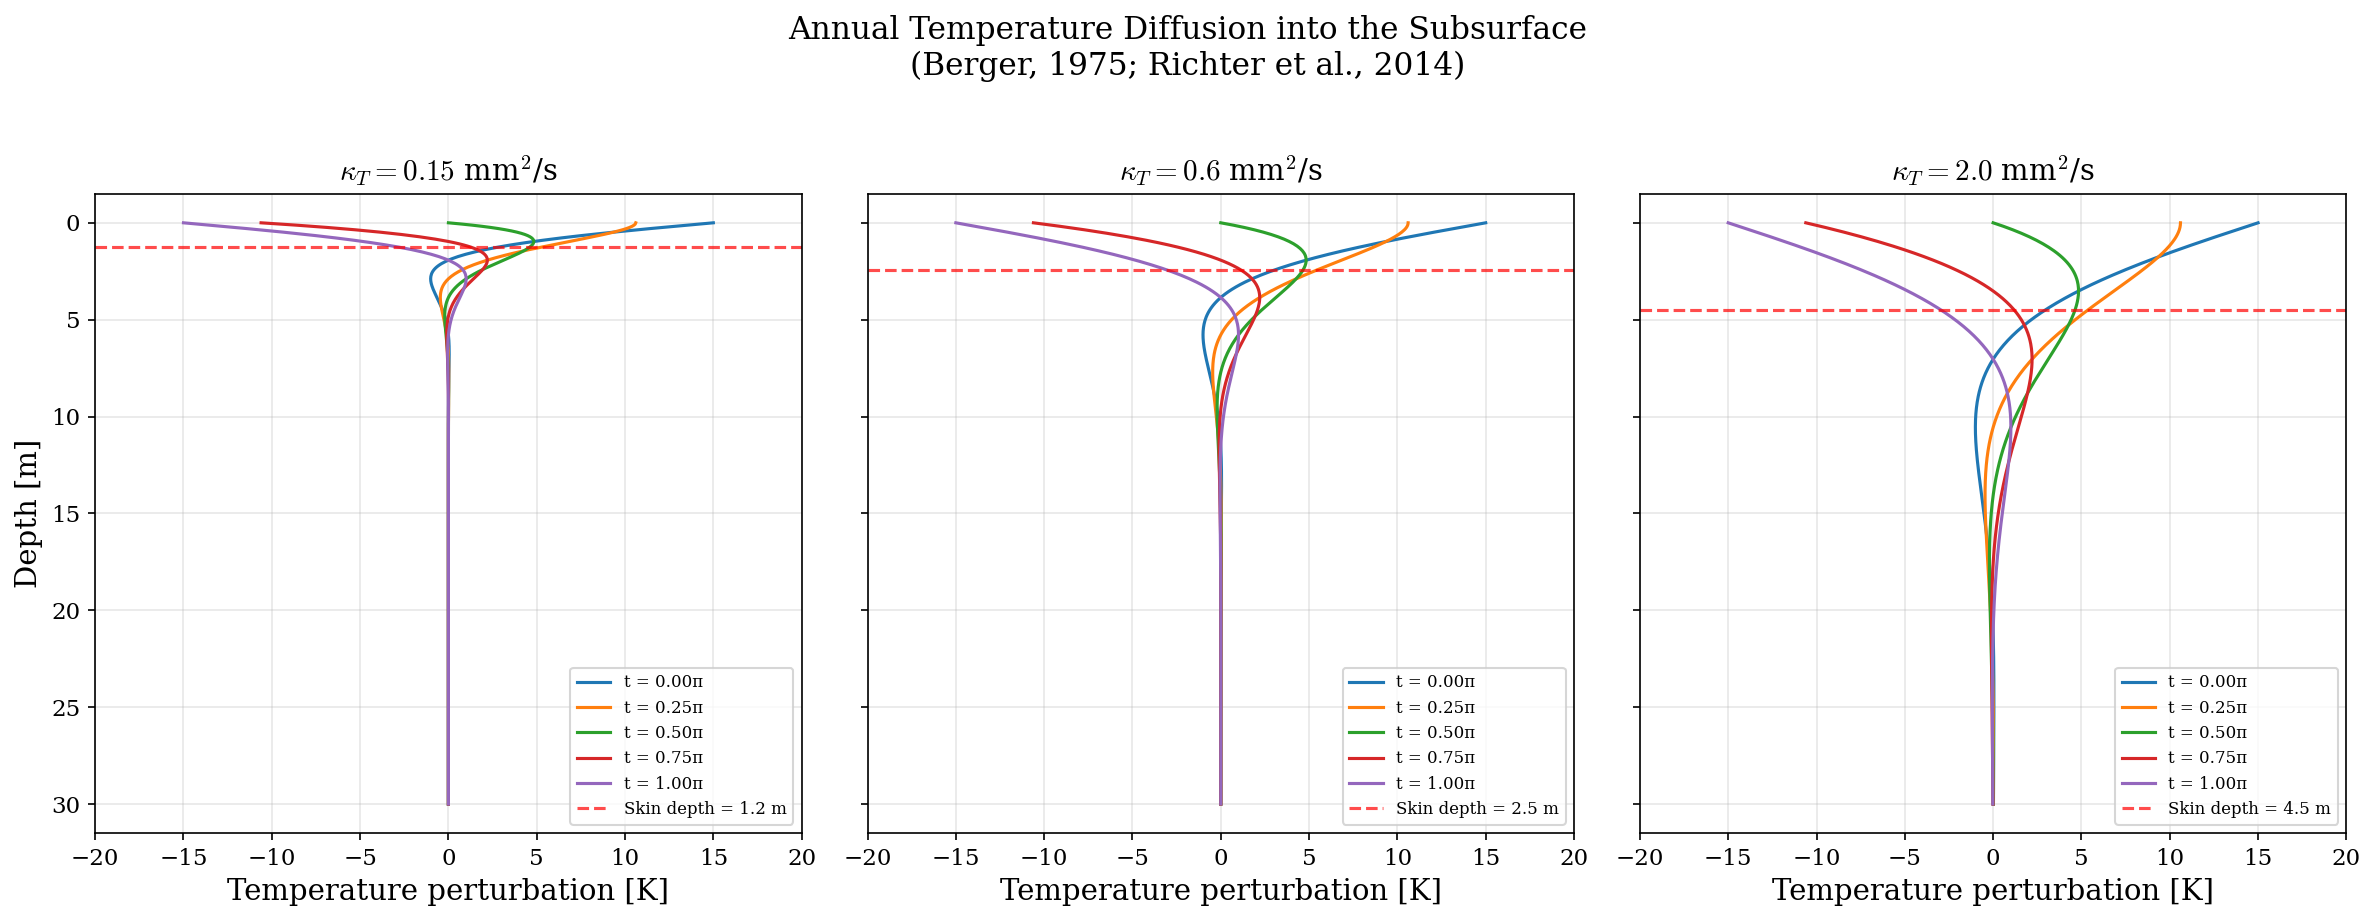

Annual skin depths: ['1.23 m', '2.46 m', '4.48 m']
Daily skin depths: ['0.064 m', '0.128 m', '0.235 m']


In [2]:
# === Temperature Diffusion Model ===

# Parameters
kappa_T_values = [0.15e-6, 0.6e-6, 2.0e-6]  # thermal diffusivity [m^2/s]
kappa_labels = [r'$\kappa_T = 0.15$ mm$^2$/s', r'$\kappa_T = 0.6$ mm$^2$/s', r'$\kappa_T = 2.0$ mm$^2$/s']
T0_annual = 15.0    # annual temperature amplitude [K]
T0_daily = 10.0     # daily temperature amplitude [K]
omega_annual = 2 * np.pi / (365.25 * 86400)  # annual angular frequency [rad/s]
omega_daily = 2 * np.pi / 86400              # daily angular frequency [rad/s]

z = np.linspace(0, 30, 500)  # depth [m]
t_phases = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]  # different time phases

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

for i, kappa_T in enumerate(kappa_T_values):
    ax = axes[i]
    gamma_ann = np.sqrt(omega_annual / (2 * kappa_T))
    skin_depth = 1.0 / gamma_ann
    
    for t_phase in t_phases:
        T_z = T0_annual * np.exp(-gamma_ann * z) * np.cos(t_phase - gamma_ann * z)
        phase_label = f't = {t_phase/np.pi:.2f}π'
        ax.plot(T_z, z, label=phase_label)
    
    ax.axhline(y=skin_depth, color='red', ls='--', alpha=0.7, label=f'Skin depth = {skin_depth:.1f} m')
    ax.set_xlabel('Temperature perturbation [K]')
    ax.set_title(kappa_labels[i])
    ax.invert_yaxis()
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(-20, 20)

axes[0].set_ylabel('Depth [m]')
fig.suptitle('Annual Temperature Diffusion into the Subsurface\n(Berger, 1975; Richter et al., 2014)', 
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('fig01_temperature_diffusion.png', bbox_inches='tight')
plt.show()

print(f"Annual skin depths: {[f'{1/np.sqrt(omega_annual/(2*k)):.2f} m' for k in kappa_T_values]}")
print(f"Daily skin depths: {[f'{1/np.sqrt(omega_daily/(2*k)):.3f} m' for k in kappa_T_values]}")


## 2. Thermoelastic Stress from Berger (1975)

Following Richter et al. (2014, Eq. 11), the thermoelastic stress invariant is:

$$\sigma(z) = \frac{\alpha E \, T(z=0)}{1 - \nu} \left[ -2 e^{-(1+i)\gamma z} + (1+\nu)\frac{(1-i) k}{\gamma} e^{-kz} \right]$$

where:
- $\alpha$ = linear thermal expansion coefficient ($\sim 8 \times 10^{-6}$ K$^{-1}$ for rock)
- $E$ = Young's modulus
- $\nu$ = Poisson's ratio
- $k = 2\pi / L$ = horizontal wavenumber of the temperature field
- $\gamma = \sqrt{\omega/(2\kappa_T)}$ = inverse skin depth

The first term dominates near the surface (decays with $\gamma$); the second term dominates at depth (decays with $k$).


<>:69: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:69: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_35113/2991882725.py:69: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  label=f'$\pi/k$ = {np.pi/k_horiz:.0f} m')


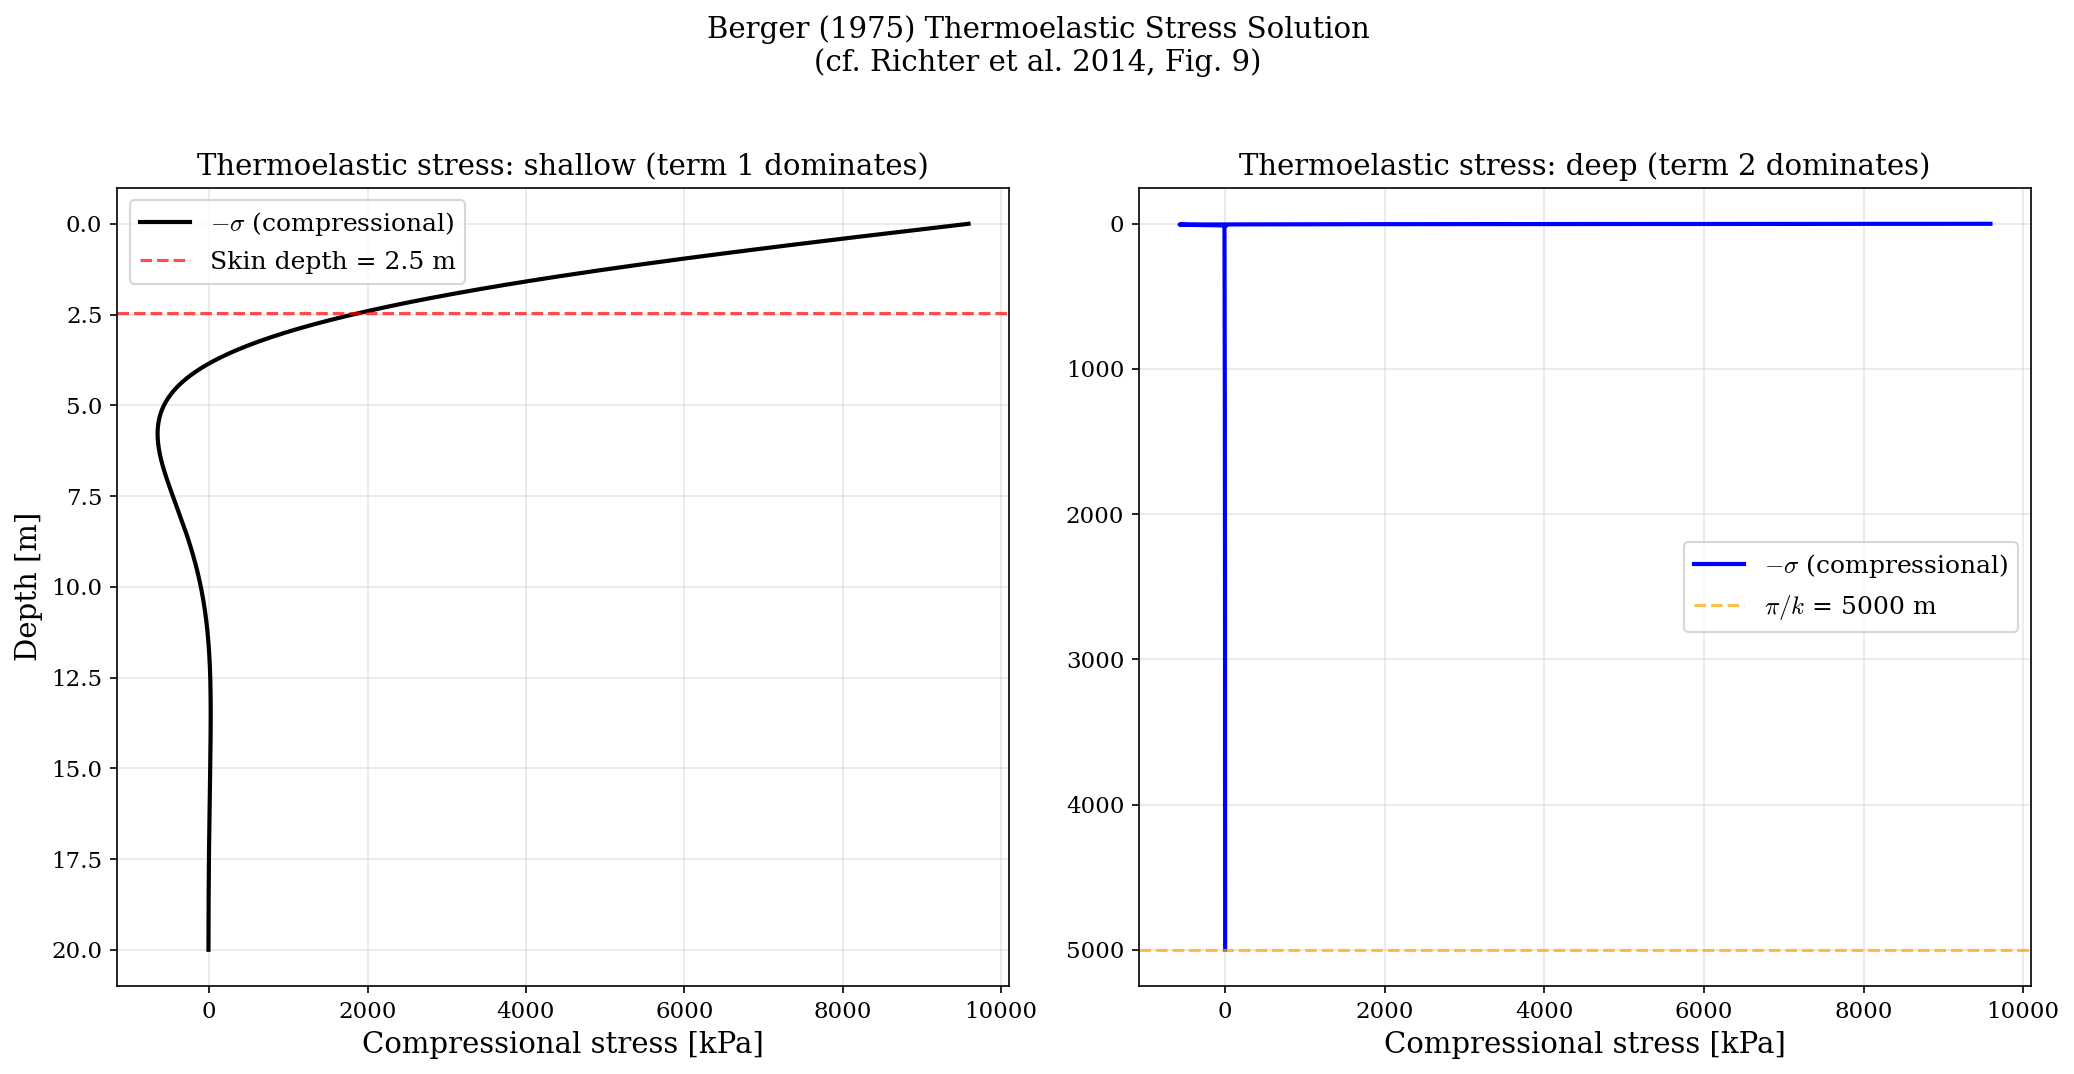

In [3]:
# === Berger (1975) Thermoelastic Stress ===

def berger_stress(z, T0, alpha_th, E, nu, gamma, k, t=0):
    """
    Compute thermoelastic stress invariant following Berger (1975)
    as formulated in Richter et al. (2014), Eq. 11.
    
    Returns real part of compressional stress components.
    """
    prefactor = alpha_th * E * T0 / (1 - nu)
    
    # Complex exponential for periodic temperature
    T_surface = np.exp(1j * t)  # normalized surface temperature
    
    # Two terms of the solution
    term1 = -2.0 * np.exp(-(1 + 1j) * gamma * z)
    term2 = (1 + nu) * (1 - 1j) * (k / gamma) * np.exp(-k * z)
    
    sigma = prefactor * (term1 + term2) * T_surface
    
    # Individual stress components (Richter 2014, Fig. 9)
    sigma_xx = prefactor * T_surface * (
        -(1 + 1j) * (k / gamma) * np.exp(-(1+1j)*gamma*z) * (1/(1-nu))
        + (1+nu)/(1-nu) * (1-1j) * (k/gamma) * np.exp(-k*z) * (1 - k*z)
    )
    sigma_yy = prefactor * T_surface * (
        -2*nu/(1-nu) * np.exp(-(1+1j)*gamma*z)
        + (1+nu)/(1-nu) * (1-1j) * (k/gamma) * np.exp(-k*z) * (2*nu - k*z)  # approximate
    )
    sigma_zz = prefactor * T_surface * (
        0  # zero at surface, builds with depth
        + (1+nu)/(1-nu) * (1-1j) * (k/gamma) * np.exp(-k*z) * (-k*z)
    )
    
    return np.real(sigma), np.real(sigma_xx), np.real(sigma_yy), np.real(sigma_zz)


# Material parameters
alpha_th = 8e-6      # thermal expansion [1/K]
E_modulus = 30e9     # Young's modulus [Pa] (typical near-surface rock)
nu = 0.25            # Poisson's ratio
kappa_T = 0.6e-6     # thermal diffusivity [m^2/s]
T0 = 15.0            # annual temperature amplitude [K]

# Wavenumbers
gamma = np.sqrt(omega_annual / (2 * kappa_T))
L_horizontal = 10e3  # horizontal wavelength [m]
k_horiz = 2 * np.pi / L_horizontal

z_deep = np.linspace(0, 5000, 2000)  # to several km
z_shallow = np.linspace(0, 20, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Shallow view
sigma_total, sx, sy, sz = berger_stress(z_shallow, T0, alpha_th, E_modulus, nu, gamma, k_horiz)
axes[0].plot(-sigma_total/1e3, z_shallow, 'k-', lw=2, label=r'$-\sigma$ (compressional)')
axes[0].axhline(y=1/gamma, color='red', ls='--', alpha=0.7, label=f'Skin depth = {1/gamma:.1f} m')
axes[0].set_xlabel('Compressional stress [kPa]')
axes[0].set_ylabel('Depth [m]')
axes[0].set_title('Thermoelastic stress: shallow (term 1 dominates)')
axes[0].invert_yaxis()
axes[0].legend()

# Deep view - second term dominates
sigma_total_d, _, _, _ = berger_stress(z_deep, T0, alpha_th, E_modulus, nu, gamma, k_horiz)
axes[1].plot(-sigma_total_d/1e3, z_deep, 'b-', lw=2, label=r'$-\sigma$ (compressional)')
axes[1].axhline(y=np.pi/k_horiz, color='orange', ls='--', alpha=0.7, 
                label=f'$\pi/k$ = {np.pi/k_horiz:.0f} m')
axes[1].set_xlabel('Compressional stress [kPa]')
axes[1].set_title('Thermoelastic stress: deep (term 2 dominates)')
axes[1].invert_yaxis()
axes[1].legend()

fig.suptitle('Berger (1975) Thermoelastic Stress Solution\n'
             '(cf. Richter et al. 2014, Fig. 9)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig02_berger_stress.png', bbox_inches='tight')
plt.show()


## 3. From Stress to Velocity Change: Third-Order Elastic Constants

The velocity change due to compressional stress $\sigma_c$ is (Richter et al., 2014, Eq. 12):

$$\frac{\Delta v}{v} = b \frac{\partial \rho v^2}{\partial \sigma_c} \frac{(1-\nu)\,\Delta\sigma_c}{E}$$

where $b$ depends on wave type:
- **P-waves**: $b = \frac{(1+\nu)(1-2\nu)}{2(1-\nu)^2} \approx 0.6$ (for $\nu=0.2$)
- **S-waves**: $b = \frac{1+\nu}{1-\nu} \approx 1.5$ (for $\nu=0.2$)

The quantity $\partial(\rho v^2)/\partial\sigma_c$ captures the **nonlinear elastic response** —
it is large for cracked/porous rocks (100–1000) and small for intact crystalline rocks (~5–10).

Combined temperature sensitivity (Ermert et al., 2023, Eq. 3):
$$s_T = 2b\alpha \frac{\partial \rho v^2}{\partial \sigma_c}$$


In [ ]:
# === dv/v from Thermoelastic Stress ===

def dvv_thermoelastic(z, T0, alpha_th, nu, kappa_T, omega, drho_v2_dsigma, wave='S'):
    """
    Compute dv/v at depth z due to thermoelastic stress.
    Combines Berger's stress solution with nonlinear elastic response.
    
    Following Richter et al. (2014) Eqs. 11-12 and Ermert et al. (2023) Eq. 2-3.
    """
    gamma = np.sqrt(omega / (2 * kappa_T))
    
    # b factor
    if wave == 'S':
        b = (1 + nu) / (1 - nu)
    else:  # P wave
        b = (1 + nu) * (1 - 2*nu) / (2 * (1 - nu)**2)
    
    # Temperature sensitivity
    s_T = 2 * b * alpha_th * drho_v2_dsigma
    
    # Temperature at depth (annual)
    T_z = T0 * np.exp(-gamma * z)
    
    # dv/v = s_T * T(z)
    dvv = s_T * T_z
    return dvv, s_T, gamma


# Parameter exploration
drho_v2_dsigma_values = [50, 200, 500, 1000]  # typical range
nu_values = [0.15, 0.20, 0.25, 0.30, 0.35]
kappa_T_range = np.linspace(0.1e-6, 3.0e-6, 50)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Panel (a): dv/v vs depth for different nonlinear responses
ax = axes[0, 0]
z_plot = np.linspace(0, 15, 300)
for drv in drho_v2_dsigma_values:
    dvv, st, gam = dvv_thermoelastic(z_plot, T0, alpha_th, 0.25, 0.6e-6, omega_annual, drv)
    ax.plot(dvv * 100, z_plot, lw=2, label=f"$\partial( \rho v^2)/\partial\sigma_c$ = {drv}")
ax.set_xlabel('dv/v [%]')
ax.set_ylabel('Depth [m]')
ax.set_title('(a) dv/v vs depth: varying nonlinear response')
ax.invert_yaxis()
ax.legend(fontsize=9)

# Panel (b): Surface dv/v vs temperature amplitude
ax = axes[0, 1]
T0_range = np.linspace(1, 30, 100)
for drv in drho_v2_dsigma_values:
    dvv_surface = []
    for T in T0_range:
        dv, _, _ = dvv_thermoelastic(np.array([0.0]), T, alpha_th, 0.25, 0.6e-6, omega_annual, drv)
        dvv_surface.append(dv[0] * 100)
    ax.plot(T0_range, dvv_surface, lw=2, label=f"$\partial( \rho v^2)/\partial\sigma_c$ = {drv}")
ax.set_xlabel('Temperature amplitude $T_0$ [K]')
ax.set_ylabel('Surface dv/v [%]')
ax.set_title('(b) Surface dv/v vs temperature amplitude')
ax.legend(fontsize=9)

# Panel (c): dv/v sensitivity to Poisson's ratio
ax = axes[1, 0]
for nu_val in nu_values:
    dvv, st, gam = dvv_thermoelastic(z_plot, T0, alpha_th, nu_val, 0.6e-6, omega_annual, 200)
    ax.plot(dvv * 100, z_plot, lw=2, label=f'$\nu$ = {nu_val}')
ax.set_xlabel('dv/v [%]')
ax.set_ylabel('Depth [m]')
ax.set_title("(c) dv/v sensitivity to Poisson's ratio")
ax.invert_yaxis()
ax.legend(fontsize=9)

# Panel (d): Skin depth vs thermal diffusivity
ax = axes[1, 1]
skin_annual = 1.0 / np.sqrt(omega_annual / (2 * kappa_T_range))
skin_daily = 1.0 / np.sqrt(omega_daily / (2 * kappa_T_range))
ax.plot(kappa_T_range * 1e6, skin_annual, 'b-', lw=2, label='Annual')
ax.plot(kappa_T_range * 1e6, skin_daily, 'r-', lw=2, label='Daily')
ax.set_xlabel('Thermal diffusivity [mm²/s]')
ax.set_ylabel('Skin depth [m]')
ax.set_title('(d) Thermal skin depth vs diffusivity')
ax.legend()
ax.set_ylim(0, 6)

fig.suptitle('Thermoelastic dv/v Sensitivity Analysis\n'
             '(Framework: Richter et al. 2014; Ermert et al. 2023)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('fig03_thermoelastic_sensitivity.png', bbox_inches='tight')
plt.show()


<>:41: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:56: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:41: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:56: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_35113/892079750.py:41: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  ax.plot(dvv * 100, z_plot, lw=2, label=f"$\partial(\rho v^2)/\partial\sigma_c$ = {drv}")
/var/folders/js/lzmy975n0l5bjbmr9db291m00000gn/T/ipykernel_35113

ValueError: 
$\partial(ho v^2)/\partial\sigma_c$ = 50
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x11845c250> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$\partial(ho v^2)/\partial\sigma_c$ = 50
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$\partial(ho v^2)/\partial\sigma_c$ = 50
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 2100x1800 with 4 Axes>

## 4. Synthetic Seasonal dv/v Time Series

We now construct a synthetic annual + sub-annual thermoelastic dv/v signal,
mimicking what is observed at Parkfield (Okubo et al., 2024) and in Chile (Richter et al., 2014).

The surface temperature is expanded as a Fourier series (Ermert et al., 2023):
$$T(t) = \sum_{n=1}^{N} A_n \cos(n\omega_0 t + \phi_n)$$

Each harmonic diffuses with its own skin depth $\gamma_n = \sqrt{n\omega_0/(2\kappa_T)}$.


In [ ]:
# === Synthetic Seasonal dv/v ===

days = np.arange(0, 365*5, 1)  # 5 years, daily
t = days * 86400  # seconds

# Synthetic temperature: annual + semi-annual + daily
T_annual = 15.0 * np.cos(2*np.pi*days/365.25)
T_semiannual = 3.0 * np.cos(4*np.pi*days/365.25 + 0.5)
T_daily = 10.0 * np.cos(2*np.pi*days/1.0)  # for daily we just add noise-like
np.random.seed(42)
T_noise = np.random.normal(0, 2, len(days))
T_surface = T_annual + T_semiannual + T_noise

# Compute dv/v using simple linear model: dv/v = s_T * T(t - t_shift)
# (Okubo et al. 2024 simplified approach)
s_T_values = [1e-4, 5e-4, 1e-3]  # temperature sensitivity
t_shift_days = [0, 15, 30, 60]  # phase shift [days]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: Temperature
axes[0].plot(days/365.25, T_surface, 'k-', lw=0.5, alpha=0.7)
axes[0].plot(days/365.25, T_annual + T_semiannual, 'r-', lw=1.5, label='Fourier fit')
axes[0].set_ylabel('Temperature anomaly [K]')
axes[0].set_title('(a) Synthetic surface temperature')
axes[0].legend()

# Panel 2: dv/v for different sensitivities
for st in s_T_values:
    dvv = st * (T_annual + T_semiannual) * 100  # in percent
    axes[1].plot(days/365.25, dvv, lw=1.5, label=f'$s_T$ = {st:.0e}')
axes[1].set_ylabel('dv/v [%]')
axes[1].set_title('(b) Thermoelastic dv/v for different sensitivities')
axes[1].legend()

# Panel 3: dv/v with different time shifts (mimicking diffusion delay)
st_fixed = 5e-4
for shift in t_shift_days:
    T_shifted = np.roll(T_annual + T_semiannual, shift)
    dvv = st_fixed * T_shifted * 100
    axes[2].plot(days/365.25, dvv, lw=1.5, label=f'shift = {shift} days')
axes[2].set_ylabel('dv/v [%]')
axes[2].set_xlabel('Time [years]')
axes[2].set_title('(c) Effect of thermal diffusion time delay (cf. Okubo et al. 2024, $t_0^{shift}$)')
axes[2].legend()

fig.suptitle('Thermoelastic Contribution to dv/v Time Series', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig04_synthetic_thermoelastic_dvv.png', bbox_inches='tight')
plt.show()

print("Note: Okubo et al. (2024) constrain t_shift to 0-90 days for Parkfield.")
print("Ermert et al. (2023) use Fourier expansion with 5 terms for Mexico City.")


## 5. Key Findings and Validity Ranges

### When is the thermoelastic model valid?

| Condition | Typical Range | Notes |
|-----------|---------------|-------|
| Thermal diffusivity $\kappa_T$ | 0.15–2.0 mm²/s | Sediments lower, crystalline rock higher |
| Annual skin depth | 1–4 m | Dominates seasonal dv/v |
| Daily skin depth | 0.05–0.20 m | Affects very high-frequency dv/v |
| $\partial(\rho v^2)/\partial\sigma_c$ | 50–1000 | Highly variable; salt crusts ~1000 (Richter 2014) |
| Temperature sensitivity $s_T$ | $10^{-5}$–$10^{-3}$ /K | Product of material properties |
| Typical dv/v amplitude | 0.01%–0.3% | Annual; depends on climate & material |

### Assumptions that may break down:
1. **Homogeneous half-space**: Real geology is layered → need surface-wave sensitivity kernels
2. **Linear superposition**: Fails when strains become large or cracks interact
3. **Plane strain**: Topography and lateral heterogeneity ignored
4. **Constant material properties**: In reality, $\partial(\rho v^2)/\partial\sigma_c$ varies with confining pressure
